# This is going to be the first iteration of my graphs for my orchestrator

- The first task was to check the win-rate of an agent change as we changed their meta data.
- So we first had ZEN vs GARNET.
- They were my custom AI that would do an action every 6 frames.
- I realized real fast that using wall time was affecting their performance, because in headless mode, time doesn't move the same.
- Hence, we will have 2 graphs, showing headless and visual. They are really the same.

## Agent Settings

- They will do a kick (if in range) every 6 frames, otherwise, they will walk.
- We read their range from their motion data.

### Task

We are going to write something that will fetch the results and graph them plainly

In [ ]:
%load_ext autoreload
%autoreload 2

import os
import pathlib
import re
import functions as f

import pandas

import constants as c
import MotionClasses.MotionEditor as me
from MotionClasses.MotionHeaders import MotionHeaders as headers
from MotionClasses.MotionNames import MotionNames as command_names

experiment_name: str = 'mcts_z_l_z_d_u_l_ge_u_z_sx_u_z_hae_u_l_hd_d'
# experiment_name: str = 'mcts_z_l_z_d_u_l_ge_u2_z_sx_u_z_hae2_u_l_hd_d02'

custom_motion_folder = os.path.join('custom_motions', experiment_name)
characters = [
    c.CHARACTERS.ZEN,
    c.CHARACTERS.LUD,
]

motion_diffs_player_one = me.get_motion_diffs(
    characters[0],
    [
        me.read_motion_file(motion_file)  #
        for motion_file in pathlib.Path(custom_motion_folder).glob(f'{characters[0].lower()}*.csv')
    ],
)

motion_diffs_player_two = me.get_motion_diffs(
    characters[1],
    [
        me.read_motion_file(motion_file)  #
        for motion_file in pathlib.Path(custom_motion_folder).glob(f'{characters[1].lower()}*.csv')
    ],
)

player_one_changed_motion_headers = [*motion_diffs_player_one.columns]
player_two_changed_motion_headers = [*motion_diffs_player_two.columns]

# Right now we are coding under the assumption that we are incrementing the values for all motions.
# Once we upgrade to using the genetic algorithm, this will need refinement

gathered_player_one_motion_diffs: list[pandas.DataFrame] = []
gathered_player_two_motion_diffs: list[pandas.DataFrame] = []

for player_one_changed_motion_header in player_one_changed_motion_headers:
    motion_name = me.get_non_0_motion_name_in_diff(motion_diffs_player_one, player_one_changed_motion_header)
    gathered_player_one_motion_diffs.append(motion_diffs_player_one.xs(motion_name, level=1)[player_one_changed_motion_header])

for player_two_changed_motion_header in player_two_changed_motion_headers:
    motion_name = me.get_non_0_motion_name_in_diff(motion_diffs_player_two, player_two_changed_motion_header)
    gathered_player_two_motion_diffs.append(motion_diffs_player_two.xs(motion_name, level=1)[player_two_changed_motion_header])

player_one_changed_motion_headers = [f'{characters[0].lower()} - {player_one_changed_motion_header}' for player_one_changed_motion_header in player_one_changed_motion_headers]
player_two_changed_motion_headers = [f'{characters[1].lower()} - {player_two_changed_motion_header}' for player_two_changed_motion_header in player_two_changed_motion_headers]

motion_diffs_player_one = pandas.concat(
    gathered_player_one_motion_diffs,
    axis=1,
    keys=player_one_changed_motion_headers,
)

motion_diffs_player_two = pandas.concat(
    gathered_player_two_motion_diffs,
    axis=1,
    keys=player_two_changed_motion_headers,
)

experiment_regex = re.compile(rf'{re.escape(experiment_name)}_(\d+).*\.csv')

match_results: list[pandas.DataFrame] = []

for experiment_file in pathlib.Path('log/point').glob('*.csv'):
    match = experiment_regex.search(experiment_file.name)

    if match:
        experiment_number = int(match.group(1))
        match_result = f.read_match_results(experiment_file)

        match_result[c.PointHeaderNames.SIMULATION_NUMBER] = experiment_number
        match_result[c.PointHeaderNames.SIMULATION_NUMBER] = match_result[c.PointHeaderNames.SIMULATION_NUMBER].astype('int16')
        match_results.append(match_result)

match_results: pandas.DataFrame = pandas.concat(match_results, ignore_index=True)
match_results.set_index(c.PointHeaderNames.SIMULATION_NUMBER, inplace=True)


if not motion_diffs_player_one.empty:
    match_results = match_results.join(motion_diffs_player_one)

if not motion_diffs_player_two.empty:
    match_results = match_results.join(motion_diffs_player_two)

match_results.sort_index(inplace=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


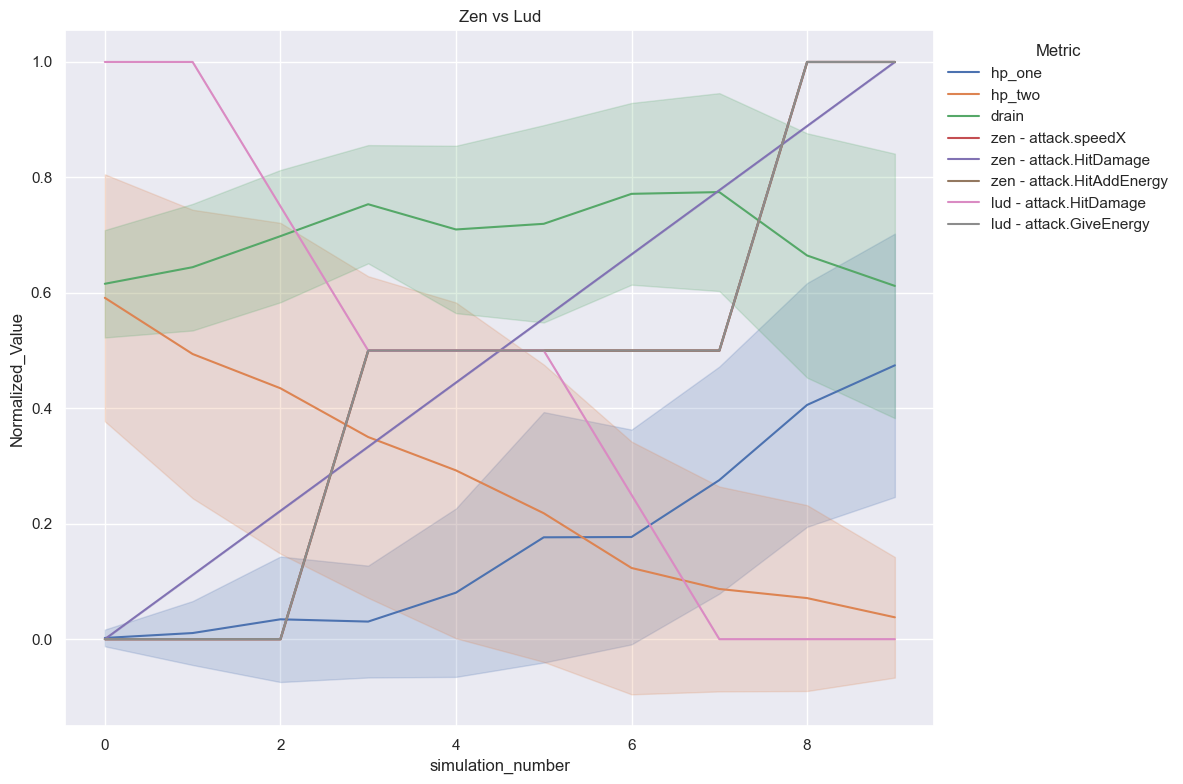

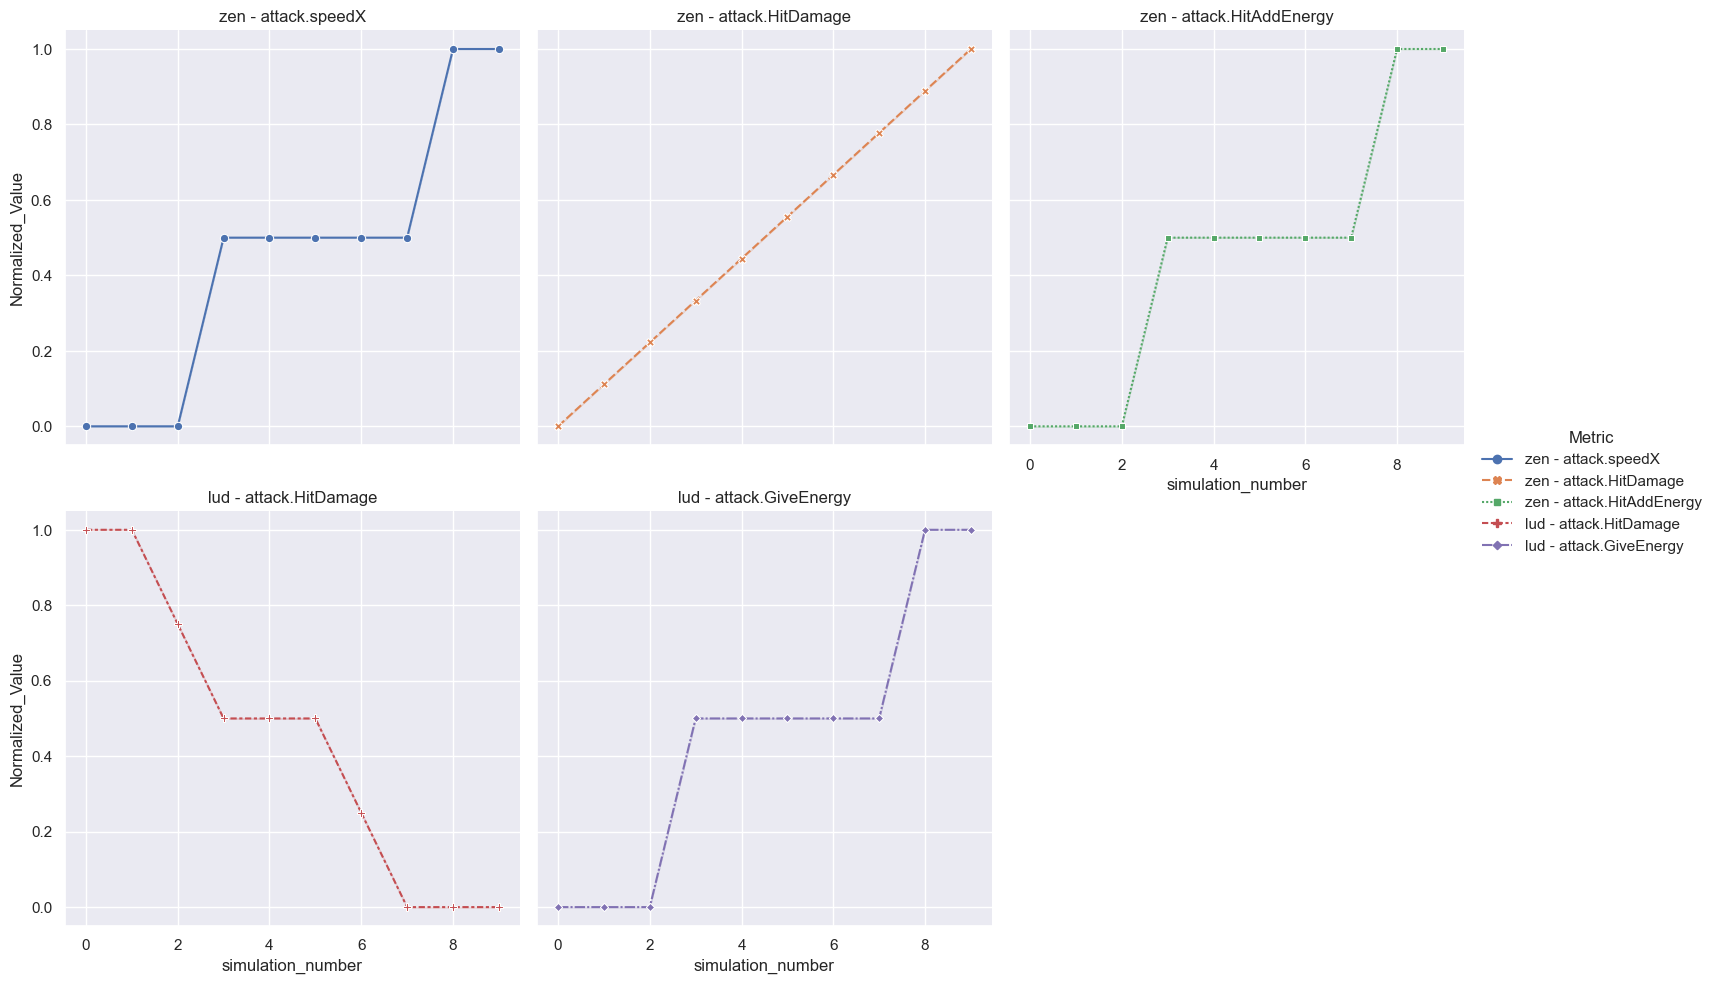

In [ ]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import seaborn as sns

import constants as c
import MotionClasses.MotionEditor as me
from MotionClasses.MotionHeaders import MotionHeaders as headers
from MotionClasses.MotionNames import MotionNames as command_names

sns.set_theme(style='darkgrid')

plot_data = match_results.copy().reset_index()

plot_data[c.PointHeaderNames.HP_ONE] /= c.PLAYER_HP
plot_data[c.PointHeaderNames.HP_TWO] /= c.PLAYER_HP
plot_data[c.PointHeaderNames.DRAIN] /= c.GAME_DURATION_SEC * 60

for player_one_changed_motion_header in player_one_changed_motion_headers:
    data_max = plot_data[player_one_changed_motion_header].max()
    data_min = plot_data[player_one_changed_motion_header].min()
    plot_data[player_one_changed_motion_header] = (
        plot_data[player_one_changed_motion_header] / data_max  #
        if data_max != 0
        else plot_data[player_one_changed_motion_header] / data_min * -1 + 1
    )

for player_two_changed_motion_header in player_two_changed_motion_headers:
    data_max = plot_data[player_two_changed_motion_header].max()
    data_min = plot_data[player_two_changed_motion_header].min()
    plot_data[player_two_changed_motion_header] = (
        plot_data[player_two_changed_motion_header] / data_max  #
        if data_max != 0
        else plot_data[player_two_changed_motion_header] / data_min * -1 + 1
    )

plot_df_long = plot_data.melt(
    id_vars=[c.PointHeaderNames.SIMULATION_NUMBER],
    value_vars=[
        c.PointHeaderNames.HP_ONE,
        c.PointHeaderNames.HP_TWO,
        c.PointHeaderNames.DRAIN,
        *player_one_changed_motion_headers,
        *player_two_changed_motion_headers,
    ],
    var_name='Metric',
    value_name='Normalized_Value',
)


plt.figure(figsize=(12, 8))

line_plot = sns.lineplot(
    data=plot_df_long,
    x=c.PointHeaderNames.SIMULATION_NUMBER,
    y='Normalized_Value',
    # dashes=False,
    # markers=True,
    hue='Metric',
    # style='Metric',
    errorbar='sd',
)

sns.move_legend(
    line_plot,
    'upper left',
    bbox_to_anchor=(1, 1),
    frameon=False
)

# 3. Finalize labels
line_plot.set_title('Zen vs Lud')

plt.tight_layout()
plt.show()

motion_plot_data = plot_df_long[
    plot_df_long['Metric'].isin(
        [
            *player_one_changed_motion_headers,
            *player_two_changed_motion_headers,
        ]
    )
]

# 3. Create the Facet Grid
g = sns.relplot(
    data=motion_plot_data,
    x=c.PointHeaderNames.SIMULATION_NUMBER,
    y='Normalized_Value',
    col='Metric',
    col_wrap=3,
    kind='line',
    hue='Metric',
    style='Metric',
    markers=True,
)

g.set_titles('{col_name}')
plt.show()

In [3]:

from pyftg.socket.aio.gateway import Gateway
import functions as f
import constants as c

try:
    gateways = f.create_gateways(8000, 9000, limit=c.NO_ENGINES)

    # Attempt to reference the Java class
    mcts_class = gateways[0].jvm.aiinterface.MctsAi23i
    print("Success: MctsAi23i found in the Java environment!")
except Exception as e:
    print(f"Error: Could not find MctsAi23i. {e}")

Error: Could not find MctsAi23i. 'Gateway' object has no attribute 'jvm'


In [1]:
import os
import MotionClasses.MotionEditor as me
import constants as c
import pandas

zen_motion: pandas.DataFrame = me.read_motion_file(
    os.path.join(
        c.DEFAULT_MOTIONS_PATH,
        'ZEN',
        c.MOTIONS_FILE_NAME,
    )
)

numerical_rows = zen_motion.select_dtypes('number')

In [2]:
import MotionClasses.MotionHeaders as headers

print(zen_motion.columns)
print(numerical_rows.columns)
print(headers.MotionHeaders.MAPPER)

Index(['frameNumber', 'speedX', 'speedY', 'hitAreaLeft', 'hitAreaRight',
       'hitAreaUp', 'hitAreaDown', 'state', 'attack.hitAreaLeft',
       'attack.hitAreaRight', 'attack.hitAreaUp', 'attack.hitAreaDown',
       'attack.speedX', 'attack.speedY', 'attack.StartUp', 'attack.Active',
       'attack.HitDamage', 'attack.GuardDamage', 'attack.StartAddEnergy',
       'attack.HitAddEnergy', 'attack.GuardAddEnergy', 'attack.GiveEnergy',
       'attack.ImpactX', 'attack.ImpactY', 'attack.GiveGuardRecov',
       'attack.AttackType', 'attack.DownProp', 'cancelAbleFrame',
       'cancelAbleMotionLevel', 'motionLevel', 'control', 'landingFlag',
       'Image'],
      dtype='str')
Index(['frameNumber', 'speedX', 'speedY', 'hitAreaLeft', 'hitAreaRight',
       'hitAreaUp', 'hitAreaDown', 'attack.hitAreaLeft', 'attack.hitAreaRight',
       'attack.hitAreaUp', 'attack.hitAreaDown', 'attack.speedX',
       'attack.speedY', 'attack.StartUp', 'attack.Active', 'attack.HitDamage',
       'attack.GuardDa

In [ ]:
import numpy as np
from scipy.spatial.distance import pdist

t = np.array([
    [['g', 'g']],
    [['f', 'g']]
])

# print((t[0] - t[1]).sum())
# print(np.linalg.norm(t[0] - t[1]))

# print(np.sum(np.sqrt(pdist(t.reshape(2, -1), metric='hamming') * t.shape[1])))
pdist(t.reshape(2, -1), metric='hamming')

ValueError: Unsupported dtype <U1

In [2]:
from MotionClasses.MotionNames import MotionNames as motion_names
from MotionClasses.MotionHeaders import MotionHeaders as headers
import numpy as np
import functions as f
import constants as c


motion_rows = np.array([
    motion_names.MAPPER[motion_names.STAND_A],
    motion_names.MAPPER[motion_names.STAND_B],
])

header_cols = np.array([
    headers.HEADERS.index(headers.ATTACK_HIT_DAMAGE),
    headers.HEADERS.index(headers.ATTACK_HIT_ADD_ENERGY),
])

print(np.stack([motion_rows, header_cols]).T)

# 0: stand a d
# 1: stand b hae
variable_mapper = f.motion_cord_to_index_bulk(np.stack([motion_rows, header_cols]).T)
print(variable_mapper)
remapped_variable_mapper = f.motion_indices_to_cords(np.array(variable_mapper))
print(remapped_variable_mapper)
# delta_map = np.zeros(shape=zen_motion.shape, dtype=np.int64)

[[27 17]
 [28 20]]
[1529, 1588]
[[27 17]
 [28 20]]


In [7]:
import numpy as np

t = np.array([
    [1, 2],
    [3, 4]
])

rows = [0, 1]
cols = [1, 0]

t[rows, cols] = -1

print(t)

[[ 1 -1]
 [-1  4]]


In [5]:
import constants as c


AttributeError: 'CHARACTERS' object has no attribute 'index'

# Pymoo tester

In [1]:
import constants as c

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from GeneticAlgorithm.FightingIceProblem import FightingIceProblem
from pymoo.termination import get_termination

res = minimize(
    FightingIceProblem(),
    NSGA2(pop_size=2),
    get_termination(c.pymoo.TERMINATION.EVALUATION_LIMIT, 1),
    seed=1,
    save_history=True,
    verbose=True
)

Index(['frameNumber', 'speedX', 'speedY', 'hitAreaLeft', 'hitAreaRight',
       'hitAreaUp', 'hitAreaDown', 'state', 'attack.hitAreaLeft',
       'attack.hitAreaRight', 'attack.hitAreaUp', 'attack.hitAreaDown',
       'attack.speedX', 'attack.speedY', 'attack.StartUp', 'attack.Active',
       'attack.HitDamage', 'attack.GuardDamage', 'attack.StartAddEnergy',
       'attack.HitAddEnergy', 'attack.GuardAddEnergy', 'attack.GiveEnergy',
       'attack.ImpactX', 'attack.ImpactY', 'attack.GiveGuardRecov',
       'attack.AttackType', 'attack.DownProp', 'cancelAbleFrame',
       'cancelAbleMotionLevel', 'motionLevel', 'control', 'landingFlag',
       'Image'],
      dtype='str')
adjustments [[204 285]
 [ 57 284]
 [124 126]]
Index(['frameNumber', 'speedX', 'speedY', 'hitAreaLeft', 'hitAreaRight',
       'hitAreaUp', 'hitAreaDown', 'state', 'attack.hitAreaLeft',
       'attack.hitAreaRight', 'attack.hitAreaUp', 'attack.hitAreaDown',
       'attack.speedX', 'attack.speedY', 'attack.StartUp', 'att

# Experiment:
- Only going to track the uniqueness, and see if the constraint novelty search is working as expected. 

In [2]:
import constants as c

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from GeneticAlgorithm.FightingIceProblem import FightingIceProblem
from pymoo.termination import get_termination

res = minimize(
    problem=FightingIceProblem(),
    algorithm=NSGA2(),
    # termination=get_termination(c.pymoo.TERMINATION.EVALUATION_LIMIT, 1),
    termination=None,
    seed=1,
    save_history=True,
    verbose=True
)

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      100 |      1 |             - |             -
     2 |      200 |      1 |  0.0000185466 |             f
     3 |      300 |      1 |  0.0000354884 |             f
     4 |      400 |      1 |  0.0000403414 |             f
     5 |      500 |      1 |  0.0000403414 |             f
     6 |      600 |      1 |  0.0000472024 |             f
     7 |      700 |      1 |  0.0000546628 |             f
     8 |      800 |      1 |  0.0000597253 |             f
     9 |      900 |      1 |  0.0000617201 |             f
    10 |     1000 |      1 |  0.0000619042 |             f
    11 |     1100 |      1 |  0.0000644690 |             f
    12 |     1200 |      1 |  0.0000644690 |             f
    13 |     1300 |      1 |  0.0000649519 |             f
    14 |     1400 |      1 |  0.0000659947 |             f
    15 |     1500 |      1 |  0.0000695840 |             f
    16 |     1600 |      1 |  0.0000698408 |            

In [15]:
import numpy as np

# np.set_printoptions(suppress=True, precision=4)
for row in res.X:
    print(", ".join(row.astype('str')))

399.93226314515266, 299.4423068072348, 0.05884925541761712, 0.026299998874231175, 399.34464913355885, 299.8868717855024
399.9227079003402, 299.53832278484396, 0.13678491524445924, 0.23535597136999742, 399.2252657626022, 299.8983160689791
399.9494690309057, 299.9832187829238, 0.009407507985861105, 0.05466778163187115, 399.31356639121543, 299.9012108927116
399.9231529776199, 299.4231674587957, 0.01297021550028158, 0.2416420048208343, 399.5116585497791, 299.9173065175919
399.87411006133794, 299.36805811175395, 0.12146351562415215, 0.05511091927416154, 399.8990933336292, 299.9767155313372
399.9205995695043, 299.92648311729084, 0.013308760082504645, 0.22809324567456174, 399.6505969134424, 299.91809766746803
399.4489031623429, 299.56708303535845, 0.11413635943234726, 0.05660941008545462, 399.9975293976245, 299.49378835721086
399.41756019231, 299.9339000049911, 0.18943676153889955, 0.23252547303931875, 399.9252437845029, 299.45778833109506
399.54356894148214, 299.39323419257704, 0.14714376621

# Experiment Results

We can observe that constraint novelty search is doing its JOB!
However, MASSIVE HOWEVER, we are not punishing the algorithm for producing agents that are close to each other.
We need to rethink how we can set this variable...
These results show that Zen is VERY different from Garnet, and Lud is VERY different from Garnet.
However! Zen is EXTREMELY similar to Lud.
This isn't punished and it needs to be.

# Experiment 2
Migrated to using a harmonic mean between the 3 objectives. 
Inspiration from F1 score calculation. 
Lets see how it goes

In [1]:
import constants as c

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from GeneticAlgorithm.FightingIceProblem import FightingIceProblem
from pymoo.termination import get_termination

res = minimize(
    problem=FightingIceProblem(),
    algorithm=NSGA2(),
    # termination=get_termination(c.pymoo.TERMINATION.EVALUATION_LIMIT, 1),
    termination=None,
    seed=1,
    save_history=True,
    verbose=True
)

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      100 |      1 |             - |             -
     2 |      200 |      1 |  0.0000198406 |             f
     3 |      300 |      1 |  0.0000464823 |             f
     4 |      400 |      1 |  0.0000467054 |             f
     5 |      500 |      1 |  0.0000574494 |             f
     6 |      600 |      1 |  0.0000700497 |             f
     7 |      700 |      1 |  0.0000700497 |             f
     8 |      800 |      1 |  0.0000726392 |             f
     9 |      900 |      1 |  0.0000741341 |             f
    10 |     1000 |      1 |  0.0000743250 |             f
    11 |     1100 |      1 |  0.0000777790 |             f
    12 |     1200 |      1 |  0.0000777790 |             f
    13 |     1300 |      1 |  0.0000796056 |             f
    14 |     1400 |      1 |  0.0000818020 |             f
    15 |     1500 |      1 |  0.0000818020 |             f
    16 |     1600 |      1 |  0.0000830975 |            

In [2]:
import numpy as np

# np.set_printoptions(suppress=True, precision=4)
for row in res.X:
    print(", ".join(row.astype('str')))

399.8858225244321, 299.45647328799686, 0.19659066746274245, 299.97716188686496, 399.81910636597877, 0.006772408564373094
399.30566805475206, 299.2239335541648, 0.24546604277853462, 299.97800435645945, 399.86660156846955, 0.006970331743444214
399.97316567679417, 299.9531338625302, 0.005190903877503372, 299.99507764269, 399.9714420874886, 0.009277255092904068
399.97301675695843, 299.9490374673383, 0.010762783485098265, 299.9818982718737, 399.81563547791933, 0.0007274610335223364
399.575098685198, 299.5145007369701, 0.16529756442670085, 299.97365121627723, 399.71291726097695, 0.05212681360339992
399.6050393166103, 299.65366095760123, 0.06000592626351989, 299.80386475127887, 399.97442769137086, 0.05210381754958333
399.31941456135786, 299.8090160398842, 0.044535505826001055, 299.9836226712239, 399.99079799419974, 0.001796720606479174
399.99774612394503, 299.9447641258445, 0.19031732448958194, 299.895738030752, 399.7984313289378, 0.005467477495351198
399.5277543958599, 299.9464488052968, 0.1

# Experiment Results

We can now see better behavior
Zen is high in both
Garnet is low in the first, and high in the second
Lud is high in the first, and low in the second

# Experiment: Competitive Balance

We are going to have a look into that now. How fast and all.
If its too slow, we can look into parallelizing it, else, running more engines first

### Speed up notes
- This experiment was done on 20 nodes with 20 cores each!
- Starting to realize there might be an oversight...
- Go setup another experiment before tomorrow to show the speed up.
- We essentially only used 10 nodes, not all 20.
- We had a 45% utilization...

### Experiment Results
- We ran our first successful experiment on the cluster
- We only balanced competitive balance
- $\sigma$ was set to 0.2 because it seems that the GA struggles to efficiently learn when its at its usual value of 0.08.
- However, to be fair, there could have been other issues with those runs. So we will need to try them again.
- And if you look at these results!!! 
- So beautiful. 
- Got 20 non-dominated solutions.
- Only took 23 minutes (underutilized cluster though!)

### Notes for further work
- The variance in the experiments is very high. We need to perform experiments to find the optimal number of experiments 

In [ ]:
import functions as f
f.read_results('res_long_exp_02')

  gen |  n_eval | n_nds |          eps
---------------------------------------------
time sec: 1366
    1 |      20 |     2 |    -0.953904
    2 |      40 |    13 |    -0.953904
    3 |      60 |    15 |    -0.953904
    4 |      80 |    20 |    -0.953904
    5 |     100 |    20 |    -0.953904
    6 |     120 |    20 |    -0.953904
    7 |     140 |    20 |    -0.953904
    8 |     160 |    20 |    -0.953904
    9 |     180 |    20 |    -0.953904
   10 |     200 |    20 |    -0.953904
non dominated solutions
Gene: [272, 212, 191, 60, 309, 54]
Fitness: [ 0.         -0.95390395]

Gene: [272, 212, 191, 60, 309, 54]
Fitness: [ 0.         -0.95390395]

Gene: [272, 212, 191, 60, 309, 54]
Fitness: [ 0.         -0.95390395]

Gene: [272, 212, 191, 60, 309, 54]
Fitness: [ 0.         -0.95390395]

Gene: [272, 212, 191, 60, 309, 54]
Fitness: [ 0.         -0.95390395]

Gene: [270, 192, 289, 284, 309, 54]
Fitness: [ 0.         -0.95390395]

Gene: [270, 192, 289, 284, 309, 54]
Fitness: [ 0.         -

# Progress report

- So we have ran 2 experiments
- Testing uniqueness, and testing competitive balance.
- We have 1 of 2 tasks to pick from:
1. We make those experiments to find stable results
2. We work on uniqueness and competitive balance.
- TBH, I think they can both be done at the same time...
- So lets start with that.
- Also, one thing to note, I can already foresee some points of improvement...
- The genes that the GA comes up with are too high...
- Thats because to achieve this balance, it can be done at almost any threshold, as long as everything else stays the same.
- Hence, we will need to create some "excitement" metric of something along those lines.
- These 2 objectives alone aren't enough...

# Experiment
- We need to determine what the optimal number of runs are for reliable results.

# Experiment
- Now we had uniqueness + competitive balance
- Shockingly good results... A bit too good...
- Looks like it found max uniqueness and max competitive balance... Lets validate
- Did a small validation test (0.001699019186713894, 0.9726653350081863)
- Looks like this is really the case. 
- We can get pretty good balance not even adjusting a lot of values.
- However, as mentioned to Pravesh, we will need to look into other metrics, because the games are short and boring.

In [ ]:
import functions as f
f.read_results('res_long_both_02.pkl')

  gen |  n_eval | n_nds |          eps
---------------------------------------------
time sec: 1366
    1 |      40 |     4 |    -0.717259
    2 |      80 |    37 |    -0.997968
    3 |     120 |    21 |    -0.997968
    4 |     160 |    20 |    -0.997968
    5 |     200 |    20 |    -0.997968
    6 |     240 |    20 |    -0.997968
    7 |     280 |    23 |    -0.997968
    8 |     320 |    20 |    -0.997968
    9 |     360 |    21 |    -0.999994
   10 |     400 |    21 |    -0.999994
non dominated solutions
Gene: [159, 138, 130, 230, 174, 15]
Fitness: [-0.00170069 -0.9979675 ]

Gene: [140, 107, 144, 224, 174, 14]
Fitness: [-0.00169902 -0.99999364]

Gene: [140, 107, 144, 224, 174, 14]
Fitness: [-0.00169902 -0.99999364]

Gene: [140, 107, 144, 224, 174, 14]
Fitness: [-0.00169902 -0.99999364]

Gene: [140, 107, 144, 224, 174, 14]
Fitness: [-0.00169902 -0.99999364]

Gene: [140, 107, 144, 224, 174, 14]
Fitness: [-0.00169902 -0.99999364]

Gene: [140, 107, 144, 224, 174, 14]
Fitness: [-0.00169

# Experiment Results
- We want to find the optimal number of runs to get a consistent results with competitive balance
- Granted that the genes are random, and we replay the game x times, whats the std of said run
- Honestly.... Not what I was expecting, even the high ones had high variance

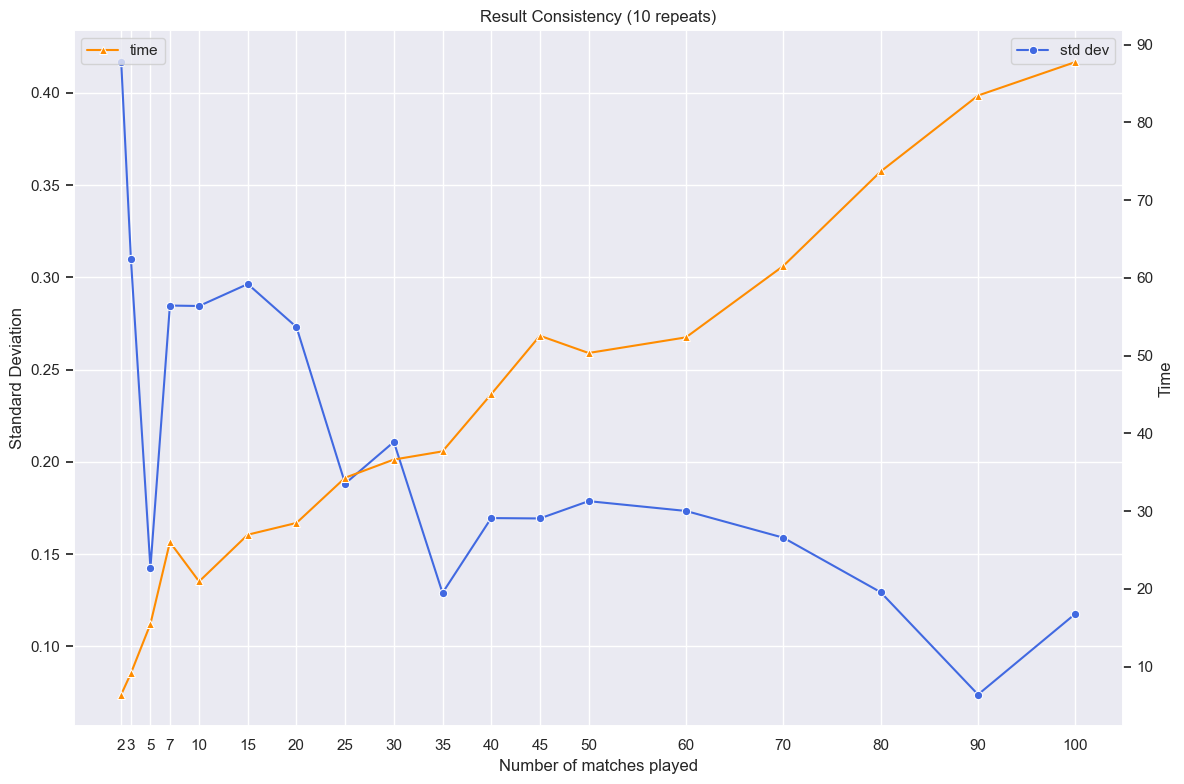

In [74]:
import numpy as np
import pathlib
import os
import re
import seaborn
import matplotlib.pyplot as plt
import pandas

import constants as c

experiment_name: str = '401d5b8a63b04179b54d019a0a38b2e5'
experiment_folder: pathlib.Path = pathlib.Path(os.path.join(c.LOGS.SOLUTION_EXPLORER, 'logs', experiment_name))

if not experiment_folder.exists():
    raise FileNotFoundError(f'Missing file: {experiment_folder.name}')

list_experiment_results: list[np.ndarray] = []
list_experiment_times: list[np.ndarray] = []
match_counts: list[str] = []

# We omit single runs because they are extremely misleading
for experiment in experiment_folder.glob('match_count*.csv'):
    pattern: str = r'match_count_(\d+).csv'
    match: re.Match = re.search(pattern, experiment.name)
    if match:
        if match.group(1) == '1':
            continue
        list_experiment_results.append(np.loadtxt(str(experiment), delimiter=',', dtype=float))
        match_counts.append(int(match.group(1)))

# match_counts = sorted(match_counts)

# Lazy code
for experiment in experiment_folder.glob('match_time*.csv'):
    pattern: str = r'match_time_(\d+).csv'
    match: re.Match = re.search(pattern, experiment.name)
    if match:
        if match.group(1) == '1':
            continue
        list_experiment_times.append(np.loadtxt(str(experiment), delimiter=',', dtype=float))

experiment_results: np.ndarray = np.stack(list_experiment_results)
experiment_times: np.ndarray = np.stack(list_experiment_times)
experiment_std: np.array = np.std(experiment_results, axis=1)

experiment_time_mean: np.array = np.mean(experiment_times, axis=1)

seaborn.set_theme(style='darkgrid', palette=seaborn.color_palette('bright'))
plt.figure(figsize=(12, 8))
axis_std = plt.gca()

line_plot = seaborn.lineplot(
    x=match_counts,
    y=experiment_std,
    marker='o',
    color='royalblue',
    label='std dev',
    ax=axis_std,
)
axis_std.set_ylabel('Standard Deviation')

axis_time = axis_std.twinx()
seaborn.lineplot(
    x=match_counts,
    y=experiment_time_mean,
    marker='^',
    label='time',
    color='darkorange',
    ax=axis_time,
)
axis_time.set_ylabel('Time')
axis_time.grid(False)

line_plot.set_title(f'Result Consistency ({experiment_results.shape[1]} repeats)')
line_plot.set_xlabel('Number of matches played')

t = experiment_std.max() + 0.1
line_plot.set_xticks(match_counts)

plt.legend()
plt.tight_layout()
plt.show()

# Experiment

- We are going to try to balance winrate without adjusting hit damage.
- We are only going to adjust give and add energy
- LETS SEE
---
- STAND_A
- STAND_B
- CROUCH_A
- CROUCH_B
- AIR_A
- AIR_B
- AIR_DA
- AIR_DB
- STAND_FA
- STAND_FB
- CROUCH_FA
- CROUCH_FB
- AIR_FA
- AIR_FB
- AIR_UA
- AIR_UB
---
- 32 genes we are adjusting!

# Experiment results
- We ran on the cluster
- no_partitions = 40, neighbours=20,  N = 20, C - 28, EM = 4 NG = 10, exp_name=mixed_exp_02_32v, gen_limit=10
- took about: 8.2 hours
- The algorithm found the optimum around generation 4...
- Might be worth looking into ways of increasing the quality of my solutions
- Because the model basically spent 6 generations doing nothing!
- But 80% comp balance isnt that bad...
- ran a small experiment, and get a lof of this... the max level for uniqueness for this example was: 0.00290169. only 0.0009 off.

In [ ]:
import functions as f
f.read_results('res_log_32V.pkl')
# time: 29595.16379585117

  gen |  n_eval | n_nds |          eps
---------------------------------------------
time sec: 1366
    1 |      40 |     5 |    -0.503728
    2 |      80 |    40 |    -0.627097
    3 |     120 |    40 |    -0.627097
    4 |     160 |    24 |    -0.806214
    5 |     200 |    20 |    -0.806214
    6 |     240 |    20 |    -0.806214
    7 |     280 |    20 |    -0.806214
    8 |     320 |    20 |    -0.806214
    9 |     360 |    20 |    -0.806214
   10 |     400 |    20 |    -0.806214
non dominated solutions
Gene: [10, 126, 140, 268, 154, 226, 210, 289, 214, 45, 204, 63, 19, 294, 291, 248, 123, 139, 36, 181, 247, 131, 72, 217, 13, 27, 11, 212, 193, 220, 82, 246, 73, 148, 276, 12, 224, 38, 76, 278, 197, 258, 83, 278, 77, 287, 81, 166, 7, 135, 140, 119, 217, 251, 33, 159, 54, 113, 196, 166, 295, 273, 297, 99, 261, 201, 144, 180, 120, 173, 58, 226, 18, 191, 14, 245, 149, 219, 284, 273, 144, 218, 100, 254, 295, 23, 300, 239, 130, 145]
Fitness: [-0.00209969 -0.80621411]

Gene: [10, 126, 140

# Similar to above
- eta set to 10
- Neighbors set to 15
- total time: 28321.432809267193 = ~8 hours

In [2]:
import functions as f
f.read_results('res_log_32V_10eta_n15.pkl')

  gen |  n_eval | n_nds |          eps
---------------------------------------------
time sec: 1366
    1 |      40 |     4 |    -0.366125
    2 |      80 |    21 |    -0.631369
    3 |     120 |    22 |    -0.764992
    4 |     160 |    22 |    -0.764992
    5 |     200 |    22 |    -0.764992
    6 |     240 |    22 |    -0.764992
    7 |     280 |    22 |    -0.764992
    8 |     320 |    22 |    -0.764992
    9 |     360 |    11 |    -0.764992
   10 |     400 |    11 |    -0.764992
non dominated solutions
Gene: [280, 291, 80, 239, 241, 126, 51, 265, 6, 285, 182, 294, 163, 135, 154, 173, 44, 124, 12, 295, 267, 242, 42, 101, 0, 147, 264, 216, 29, 279, 33, 69, 87, 170, 214, 206, 153, 60, 16, 145, 258, 62, 33, 92, 192, 289, 239, 192, 110, 105, 204, 24, 8, 126, 188, 178, 74, 145, 6, 162, 229, 9, 192, 168, 169, 141, 48, 245, 265, 131, 180, 60, 264, 286, 272, 262, 31, 155, 143, 268, 221, 261, 288, 203, 87, 103, 272, 104, 54, 36]
Fitness: [-0.14607243 -0.76499235]

Gene: [280, 291, 80, 239,

In [4]:
import functions as f
f.read_results('res.pkl')

  gen |  n_eval | n_nds |          eps
---------------------------------------------
time sec: 1366
    1 |      40 |     3 |    -0.444487
    2 |      80 |    36 |    -0.661107
    3 |     120 |    14 |    -0.690589
    4 |     160 |    14 |    -0.690589
    5 |     200 |    15 |    -0.777649
    6 |     240 |    19 |    -0.777649
    7 |     280 |    19 |    -0.777649
    8 |     320 |    19 |    -0.777649
    9 |     360 |    15 |    -0.931106
non dominated solutions
Gene: [25, 128, 170, 9, 8, 51, 47, 264, 8, 288, 162, 217, 162, 6, 154, 174, 44, 125, 32, 190, 63, 221, 86, 101, 274, 145, 6, 211, 35, 100, 19, 245, 27, 163, 273, 114, 153, 58, 16, 144, 257, 257, 33, 299, 253, 287, 83, 199, 177, 62, 206, 28, 5, 242, 189, 278, 176, 112, 180, 117, 260, 18, 264, 168, 248, 205, 10, 182, 267, 153, 225, 276, 263, 225, 89, 170, 119, 82, 152, 279, 29, 130, 291, 290, 193, 94, 269, 286, 67, 16]
Fitness: [-0.15539873 -0.93110576]

Gene: [25, 128, 170, 9, 8, 51, 47, 264, 8, 288, 162, 217, 162, 6, 15

# Experiment

- Increased spread, (theta = 10)
- ran on 10 nodes because cluster was full
- time: 28806.14643205609 = 8 hours (i wonder if my 20 nodes are even doing anything?!?)
- Got some really good results this time around... 
- Playing with theta will help a lot

In [7]:
import functions as f

f.read_results('res_l_32_10t_n15.pkl')

  gen |  n_eval | n_nds |          eps
---------------------------------------------
time sec: 1366
    1 |      40 |     3 |    -0.444487
    2 |      80 |    36 |    -0.661107
    3 |     120 |    14 |    -0.690589
    4 |     160 |    14 |    -0.690589
    5 |     200 |    15 |    -0.777649
    6 |     240 |    19 |    -0.777649
    7 |     280 |    19 |    -0.777649
    8 |     320 |    19 |    -0.777649
    9 |     360 |    15 |    -0.931106
non dominated solutions
Gene: [25, 128, 170, 9, 8, 51, 47, 264, 8, 288, 162, 217, 162, 6, 154, 174, 44, 125, 32, 190, 63, 221, 86, 101, 274, 145, 6, 211, 35, 100, 19, 245, 27, 163, 273, 114, 153, 58, 16, 144, 257, 257, 33, 299, 253, 287, 83, 199, 177, 62, 206, 28, 5, 242, 189, 278, 176, 112, 180, 117, 260, 18, 264, 168, 248, 205, 10, 182, 267, 153, 225, 276, 263, 225, 89, 170, 119, 82, 152, 279, 29, 130, 291, 290, 193, 94, 269, 286, 67, 16]
Fitness: [-0.15539873 -0.93110576]

Gene: [25, 128, 170, 9, 8, 51, 47, 264, 8, 288, 162, 217, 162, 6, 15

# Experiment

- First excitement test

In [7]:

import functions as f

f.read_results('run_results/res_excitement.pkl')

  gen |  n_eval | n_nds |          eps
---------------------------------------------
time sec: 1366
    1 |      40 |     1 |    -0.001270
    2 |      80 |    15 |    -0.002220
    3 |     120 |    15 |    -0.002220
    4 |     160 |    15 |    -0.002220
    5 |     200 |    15 |    -0.002220
    6 |     240 |    15 |    -0.002220
    7 |     280 |    15 |    -0.002220
    8 |     320 |    15 |    -0.002220
    9 |     360 |    15 |    -0.002220
non dominated solutions
Gene: [82, 184, 90, 331, 151, 266, 276, 117, 389, 50, 270, 170, 75, 46, 26, 26, 323, 199, 277, 109, 346, 185, 0, 254, 317, 161, 17, 70, 162, 140, 41, 39, 285, 173, 140, 349, 216, 321, 157, 309, 386, 272, 173, 251, 163]
Fitness: [-0.00222031  0.        ]

Gene: [82, 184, 90, 331, 151, 266, 276, 117, 389, 50, 270, 170, 75, 46, 26, 26, 323, 199, 277, 109, 346, 185, 0, 254, 317, 161, 17, 70, 162, 140, 41, 39, 285, 173, 140, 349, 216, 321, 157, 309, 386, 272, 173, 251, 163]
Fitness: [-0.00222031  0.        ]

Gene: [82, 184,

# Theory Testing

- We found a paper that gave us a way to describe excitement... 
- We are going to run some smol tests just to understand it a bit better

In [ ]:
import numpy as np
import GeneticAlgorithm.genetic_functions TODO: We can speed this up very easily

# Win probability calculations
- We are gong to be doing some graphing on this stuff
- First exps with line of best fit

In [23]:
import GeneticAlgorithm.genetic_functions as gf
import functions as f
import constants as c
import numpy as np
import seaborn as sns
import pandas as pd
import os
import json

frame_data_file_name = os.path.join(
    'log',
    c.LOGS.FRAME_DATA,
    'runner_15.31.56-2026.05.02_15.31.55.json'

)


frame_data_json: list[dict[str, any]]
with open(str(frame_data_file_name)) as file:
    frame_data_json = json.load(file)

frame_data, max_frame = gf.parse_frame_data(frame_data_json)
print(max_frame, len(frame_data))

3265 3265


In [24]:
player_one_hp_journey = np.zeros(shape=max_frame, dtype=np.float64)
player_two_hp_journey = np.zeros(shape=max_frame, dtype=np.float64)

player_one_energy_journey = np.zeros(shape=max_frame, dtype=np.float64)
player_two_energy_journey = np.zeros(shape=max_frame, dtype=np.float64)

energy_weight = 0.5

for frame_number in range(max_frame):
    frame = frame_data[frame_number]

    player_one_hp_journey[frame_number] = frame.hitPoints[0]
    player_two_hp_journey[frame_number] = frame.hitPoints[1]

    player_one_energy_journey[frame_number] = frame.energy[0]
    player_two_energy_journey[frame_number] = frame.energy[1]

player_one_hp_journey /= c.PLAYER_HP
player_two_hp_journey /= c.PLAYER_HP

player_one_energy_journey /= c.PLAYER_MAX_ENERGY
player_two_energy_journey /= c.PLAYER_MAX_ENERGY

player_one_effective_hp_journey = player_one_hp_journey + player_one_energy_journey * energy_weight
player_two_effective_hp_journey = player_two_hp_journey + player_two_energy_journey * energy_weight

epsilon = 1e-6

player_one_win_probability = player_one_effective_hp_journey / (player_one_effective_hp_journey + player_two_effective_hp_journey + epsilon)
player_two_win_probability = player_two_effective_hp_journey / (player_one_effective_hp_journey + player_two_effective_hp_journey + epsilon)

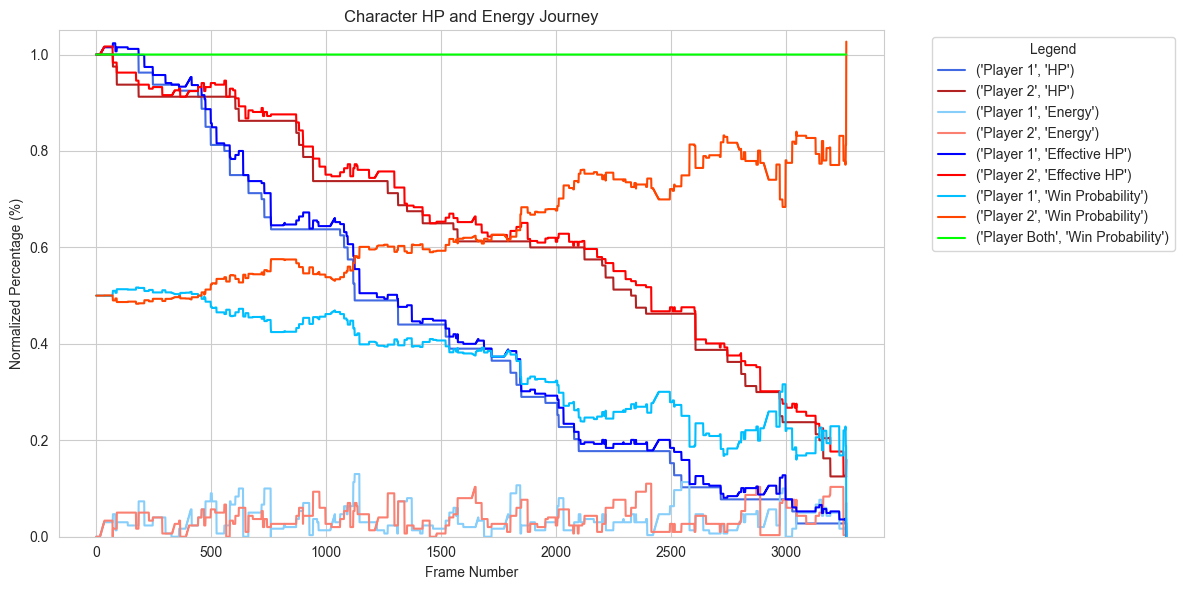

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

data = pd.DataFrame(
    {
        'Frame': np.tile(np.arange(max_frame), 9),
        'Value': np.concatenate(
            [
                player_one_hp_journey,
                player_two_hp_journey,
                player_one_energy_journey,
                player_two_energy_journey,
                player_one_effective_hp_journey,
                player_two_effective_hp_journey,
                player_one_win_probability,
                player_two_win_probability,
            ]
        ),
        'Player': np.concatenate(
            [
                ['Player 1'] * max_frame,
                ['Player 2'] * max_frame,
                ['Player 1'] * max_frame,
                ['Player 2'] * max_frame,
                ['Player 1'] * max_frame,
                ['Player 2'] * max_frame,
                ['Player 1'] * max_frame,
                ['Player 2'] * max_frame,
            ]
        ),
        'Metric': np.concatenate(
            [
                ['HP'] * max_frame,
                ['HP'] * max_frame,
                ['Energy'] * max_frame,
                ['Energy'] * max_frame,
                ['Effective HP'] * max_frame,
                ['Effective HP'] * max_frame,
                ['Win Probability'] * max_frame,
                ['Win Probability'] * max_frame,
            ]
        ),
    }
)

# 2. Define custom colors for the 'Red' and 'Blue' themes
# HP uses darker shades, Energy uses lighter shades
palette = {
    ('Player 1', 'HP'): 'royalblue',
    ('Player 1', 'Energy'): 'lightskyblue',
    ('Player 1', 'Effective HP'): 'blue',
    ('Player 2', 'HP'): 'firebrick',
    ('Player 2', 'Energy'): 'salmon',
    ('Player 2', 'Effective HP'): 'red',
    ('Player 1', 'Win Probability'): 'deepskyblue',
    ('Player 2', 'Win Probability'): 'orangered',
}

# 3. Plotting
plt.figure(figsize=(12, 6))
sns.set_style('darkgrid')

# We use 'hue' for Player and 'style' for Metric, or combine them for the palette
sns.lineplot(
    data=data,
    x='Frame',
    y='Value',
    hue=data[['Player', 'Metric']].apply(tuple, axis=1),
    palette=palette,
)

# 4. Cleanup labels and legend
plt.title('Character HP and Energy Journey')
plt.ylabel('Normalized Percentage (%)')
plt.xlabel('Frame Number')
plt.ylim(0, 1.05)  # Keeps the plot clean since values are normalized
plt.legend(title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

# Entropy score

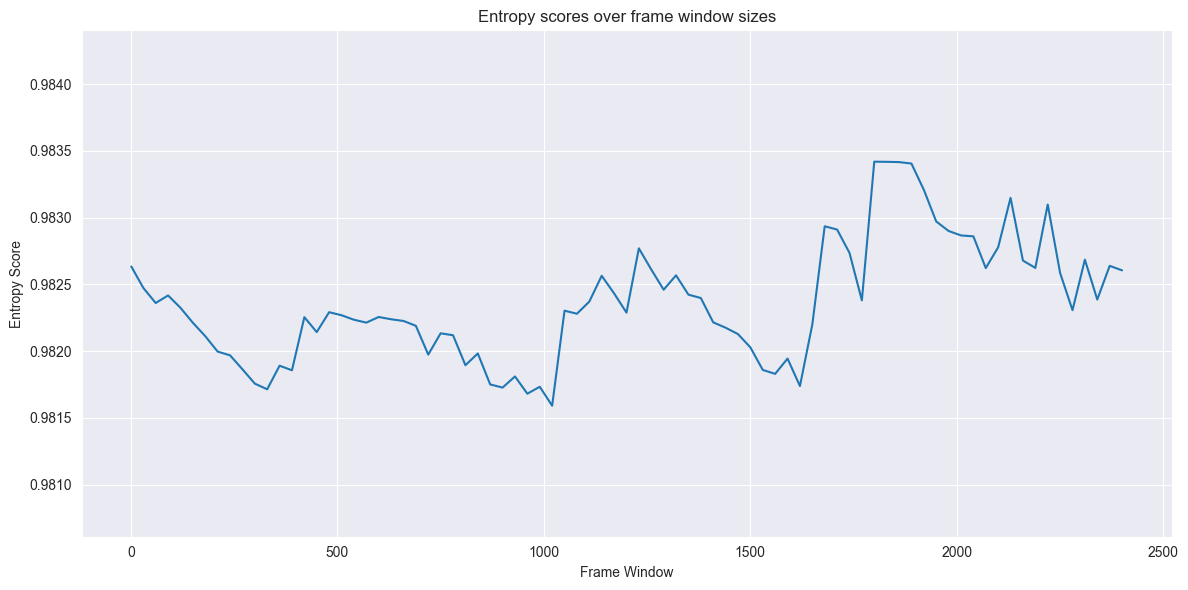

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

frame_windows = np.arange(stop=2401, step=30)
frame_windows[0] = 1
entropy_scores = np.zeros(shape=frame_windows.shape[0])

for index, frame_window in enumerate(frame_windows):
    entropy_scores[index] = gf.calculate_entropy_score([player_one_win_probability], frame_window=frame_window)

data = pd.DataFrame(
    {
        'Frame Window': frame_windows,
        'Entropy Score': entropy_scores,
    }
)

plt.figure(figsize=(12, 6))
sns.set_style('darkgrid')

# We use 'hue' for Player and 'style' for Metric, or combine them for the palette
sns.lineplot(
    data=data,
    x='Frame Window',
    y='Entropy Score',
)

# 4. Cleanup labels and legend
plt.title('Entropy scores over frame window sizes')
plt.ylim(np.min(entropy_scores) * 0.999, np.max(entropy_scores) * 1.001)  # Keeps the plot clean since values are normalized
plt.tight_layout()

plt.show()

In [47]:
print(np.argmin(entropy_scores[:28]))
print(frame_windows[11])
print(frame_windows)

11
330
[   1   30   60   90  120  150  180  210  240  270  300  330  360  390
  420  450  480  510  540  570  600  630  660  690  720  750  780  810
  840  870  900  930  960  990 1020 1050 1080 1110 1140 1170 1200 1230
 1260 1290 1320 1350 1380 1410 1440 1470 1500 1530 1560 1590 1620 1650
 1680 1710 1740 1770 1800 1830 1860 1890 1920 1950 1980 2010 2040 2070
 2100 2130 2160 2190 2220 2250 2280 2310 2340 2370 2400]


In [ ]:
import functions as f
# f.read_results('run_results/comp_p32_n10_energy.pkl')
# f.read_results('run_results/ex_cb_p32_n10_energy.pkl')
# f.read_results('run_results/excite_p32_n10_energy.pkl')
# f.read_results('run_results/uniq_p32_n10_energy.pkl')
# f.read_results('run_results/uq_cb_p32_n10_energy.pkl')
# f.read_results('run_results/uq_ex_p32_n10_energy.pkl')

  gen |  n_eval | n_nds |          eps
---------------------------------------------
time sec: 1366
    1 |      30 |     3 |    -0.685225
    2 |      60 |    21 |    -0.704389
    3 |      90 |    19 |    -0.991805
    4 |     120 |    20 |    -0.991805
    5 |     150 |    22 |    -0.991805
    6 |     180 |    20 |    -0.991805
    7 |     210 |    20 |    -0.991805
    8 |     240 |    25 |    -0.999123
    9 |     270 |    25 |    -0.999123
   10 |     300 |    18 |    -0.999123
   11 |     330 |    18 |    -0.999123
   12 |     360 |    18 |    -0.999123
non dominated solutions
Gene: [249, 290, 140, 12, 76, 73, 31, 13, 34, 147, 58, 107, 134, 109, 13, 294, 92, 58, 278, 6, 251, 38, 58, 88, 45, 282, 244, 51, 78, 46, 210, 240, 1, 7, 141, 34, 63, 25, 291, 63, 104, 136, 40, 110, 70, 266, 130, 95, 76, 21, 245, 267, 104, 142, 251, 64, 114, 36, 87, 115, 274, 191, 189, 236, 111, 218, 280, 79, 51, 175, 161, 111, 213, 75, 90, 247, 232, 7, 95, 251, 178, 140, 166, 234, 48, 6, 91, 252, 176, 26

In [4]:
import numpy as np

t = np.array([0.5483546502164361, 0.44026652198227706, 0.40478297514343103, 0.526567573716002, 0.18694160934280418, 0.38089015003811544, 0.37732850822148367, 0.5167919405536976, 0.22973633621319248, 0.472054539839959, 0.43207812996144346, 0.45529058839676906, 0.4707817516871647, 0.35725577926510377, 0.5250290692845594, 0.4366116236977237, 0.12233086000212888, 0.5086506827344841, 0.18642346132466486, 0.40124394928557927])
print("Ave:", np.average(t))
print("Max:", np.max(t))
print("Min:", np.min(t))

Ave: 0.398970535045351
Max: 0.5483546502164361
Min: 0.12233086000212888


# Compare excitement with best uniqueness + comp balance

- Compare all pairs!
- Compb -> unique -> excit
- Comb + un -> blah blah blah
- Test 4th objective for lead swap

In [1]:
from GeneticAlgorithm.ResultReplay import ResultHolder, SolutionHolder, Objectives, replay_results_and_save

results: list[ResultHolder] = [
    ResultHolder('run_results/uniq_p32_n10_energy.pkl', [Objectives.UNIQUENESS]),
    ResultHolder('run_results/excite_p32_n10_energy.pkl', [Objectives.EXCITEMENT]),
    ResultHolder('run_results/comp_p32_n10_energy.pkl', [Objectives.COMPETITIVE_BALANCE]),
    ResultHolder('run_results/uq_cb_p32_n10_energy.pkl', [Objectives.COMPETITIVE_BALANCE, Objectives.UNIQUENESS]),
    ResultHolder('run_results/uq_ex_p32_n10_energy.pkl', [Objectives.EXCITEMENT, Objectives.UNIQUENESS]),
    ResultHolder('run_results/ex_cb_p32_n10_energy.pkl', [Objectives.COMPETITIVE_BALANCE, Objectives.EXCITEMENT]),
]

replay_results_and_save(results)

Expanding experiment: run_results/uniq_p32_n10_energy_result_replay (0/6)
Evaluating solution 0/10


RuntimeError: asyncio.run() cannot be called from a running event loop